<a href="https://colab.research.google.com/github/AngelGarcia0905/IA/blob/main/Examen_MC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica de Procesamiento y Visualización de Datos
**Objetivo:** Utilizar `numpy`, `pandas` y `matplotlib` para limpiar y analizar el dataset "Diamonds".

In [15]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import sys       # Interacción con el intérprete
import pandas as pd  # Manipulación de DataFrames
import numpy as np   # Cálculo numérico y arreglos
import matplotlib as mpl # Generación de gráficos
import platform  # Información del sistema operativo
import psutil    # Monitoreo de recursos de hardware

In [16]:
# ==============================================================================
# EXTRACCIÓN DE METADATOS DEL SISTEMA Y VERSIONES DE SOFTWARE
# ==============================================================================
print("-" * 30)
print("ESPECIFICACIONES DEL SISTEMA")
print("-" * 30)
print(f"Sistema Operativo: {platform.system()} {platform.release()}") # Muestra el SO y su versión
print(f"Arquitectura: {platform.machine()}") # Indica si es x86_64 o ARM
print(f"Procesador: {platform.processor()}") # Identifica el modelo del CPU
# Memoria RAM disponible en Colab
ram_gb = round(psutil.virtual_memory().total / (1024**3), 2) # Convierte de bytes a GB
print(f"Memoria RAM Total: {ram_gb} GB")

print("\n" + "-" * 30)
print("VERSIONES DE LIBRERÍAS")
print("-" * 30)
print(f"Python version: {sys.version.split()[0]}") # Versión del intérprete
print(f"Pandas version: {pd.__version__}")        # Versión de manejo de datos
print(f"NumPy version: {np.__version__}")          # Versión de cálculo numérico
print(f"Matplotlib version: {mpl.__version__}")   # Versión de graficación

print("\n" + "-" * 30)
print("RECURSOS DE HARDWARE ESPECÍFICOS")
print("-" * 30)
# Verifica presencia de aceleración por GPU (NVIDIA) o indica si usa CPU
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv,noheader || echo "No se detectó GPU (Ejecución en CPU)"

------------------------------
ESPECIFICACIONES DEL SISTEMA
------------------------------
Sistema Operativo: Linux 6.6.113+
Arquitectura: x86_64
Procesador: x86_64
Memoria RAM Total: 12.67 GB

------------------------------
VERSIONES DE LIBRERÍAS
------------------------------
Python version: 3.12.12
Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0

------------------------------
RECURSOS DE HARDWARE ESPECÍFICOS
------------------------------
Tesla T4, 580.82.07, 15360 MiB


In [17]:
# ==============================================================================
# CARGA DEL DATASET Y ANÁLISIS ESTADÍSTICO INICIAL
# ==============================================================================
# URL del dataset en formato Raw GitHub
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"

# Cargamos el archivo CSV en un DataFrame de Pandas
df = pd.read_csv(url) # Descarga y convierte el CSV en objeto DataFrame

# Imprimimos las últimas 5 filas para verificar la carga
print("Últimas 5 filas del dataset:")
print(df.tail()) # Muestra el final de la estructura de datos

# Generamos el resumen estadístico de las columnas numéricas
print("\nResumen estadístico descriptivo:")
print(df.describe()) # Calcula media, desviación, valores min/max, etc.

Últimas 5 filas del dataset:
       carat        cut color clarity  depth  table  price     x     y     z
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

Resumen estadístico descriptivo:
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
5

In [18]:
# ==============================================================================
# LIMPIEZA DE DATOS Y CÁLCULO DE VARIABLES DERIVADAS
# ==============================================================================
# Identificamos filas con dimensiones nulas mediante una máscara lógica
filas_con_cero = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)

# Eliminamos los registros con ceros usando el operador de negación (~)
df = df[~filas_con_cero] # Filtra el DataFrame para conservar solo datos válidos

# Creamos la columna 'volumen_aprox' mediante operación vectorizada
df['volumen_aprox'] = df['x'] * df['y'] * df['z'] # Cálculo espacial (ancho * alto * profundidad)

print(f"Limpieza completada. Filas restantes: {len(df)}") # Verifica registros finales
print(df[['x', 'y', 'z', 'volumen_aprox']].head()) # Muestra las primeras 5 filas procesadas

Limpieza completada. Filas restantes: 53920
      x     y     z  volumen_aprox
0  3.95  3.98  2.43      38.202030
1  3.89  3.84  2.31      34.505856
2  4.05  4.07  2.31      38.076885
3  4.20  4.23  2.63      46.724580
4  4.34  4.35  2.75      51.917250


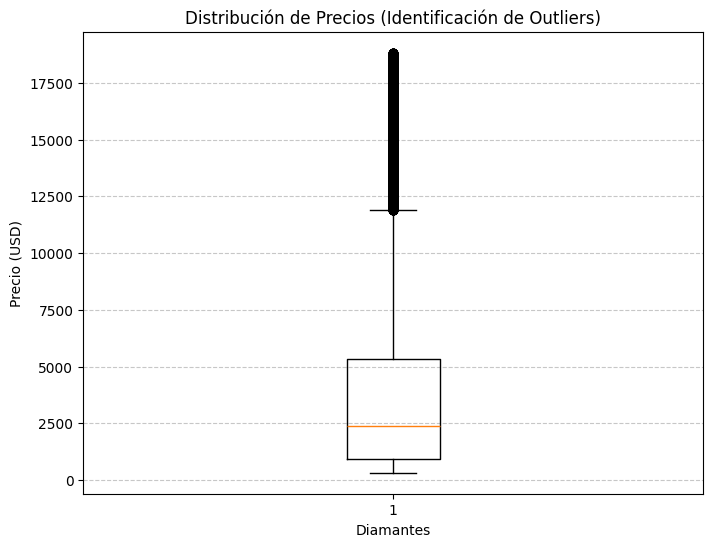

In [20]:
# ==============================================================================
# VISUALIZACIÓN 1: DISTRIBUCIÓN DE PRECIOS
# ==============================================================================
plt.figure(figsize=(8, 6))          # Define un tamaño individual para la gráfica
plt.boxplot(df['price'])            # Genera el diagrama de caja
plt.title('Distribución de Precios (Identificación de Outliers)') # Título
plt.xlabel('Diamantes')             # Etiqueta eje X
plt.ylabel('Precio (USD)')          # Etiqueta eje Y
plt.grid(axis='y', linestyle='--', alpha=0.7) # Agrega rejilla horizontal opcional
plt.show()                          # Despliega la gráfica

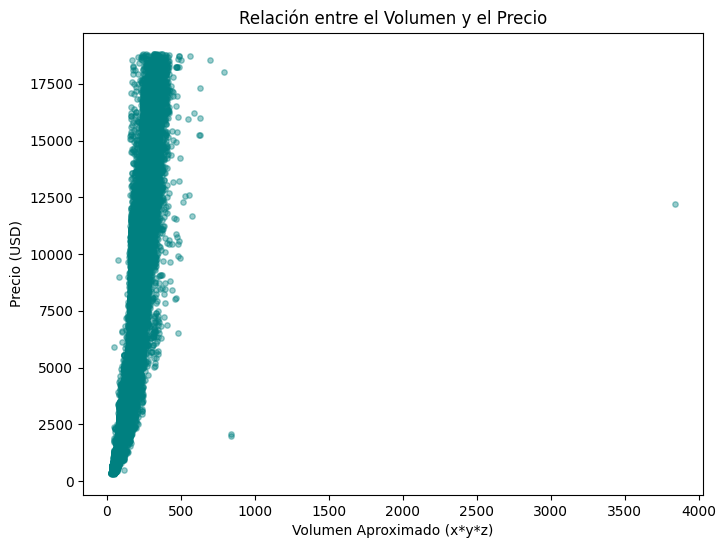

In [21]:
# ==============================================================================
# VISUALIZACIÓN 2: RELACIÓN VOLUMEN VS PRECIO
# ==============================================================================
plt.figure(figsize=(8, 6))          # Tamaño de la figura
plt.scatter(df['volumen_aprox'], df['price'], alpha=0.4, color='teal', s=15) # Gráfico de puntos
plt.title('Relación entre el Volumen y el Precio') # Título
plt.xlabel('Volumen Aproximado (x*y*z)') # Etiqueta eje X
plt.ylabel('Precio (USD)')          # Etiqueta eje Y
plt.show()                          # Despliega la gráfica

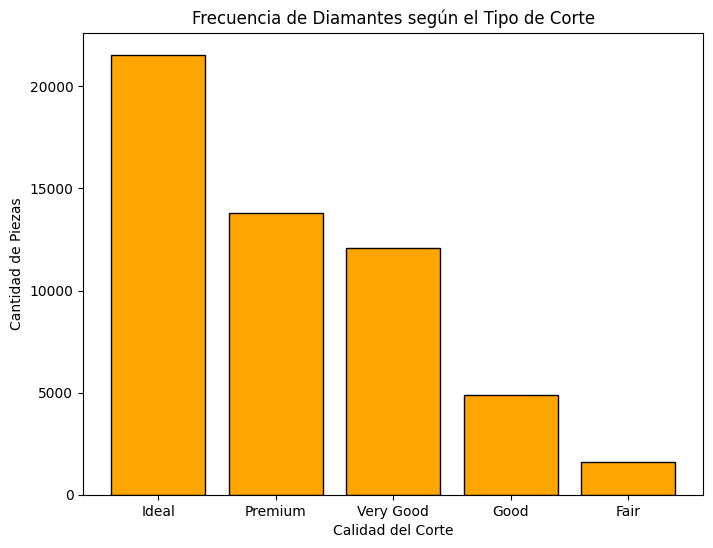

In [23]:
# ==============================================================================
# VISUALIZACIÓN 3: CANTIDAD DE PIEZAS POR TIPO DE CORTE
# ==============================================================================
plt.figure(figsize=(8, 6))          # Tamaño de la figura

# Procesamiento: Contar la frecuencia de cada categoría
conteo_cortes = df['cut'].value_counts()

# Generación de barras usando los índices (nombres) y valores (conteos)
plt.bar(conteo_cortes.index, conteo_cortes.values, color='orange', edgecolor='black')
plt.title('Frecuencia de Diamantes según el Tipo de Corte') # Título
plt.xlabel('Calidad del Corte')     # Etiqueta eje X
plt.ylabel('Cantidad de Piezas')    # Etiqueta eje Y
plt.show()                          # Despliega la gráfica